<style>
/* Page setup */
@page {
    size: Letter;
    margin: 0.75in;
}

/* Main report text */
body {
    font-family: "Times New Roman", Times, serif !important;
    font-size: 11.5pt !important;
    line-height: 1.35 !important;
    max-width: 7.2in;
    margin: auto;
    color: black;
}

/* Headings */
h1 {
    font-size: 20pt !important;
    text-align: center;
}

h2 {
    font-size: 15pt !important;
    margin-top: 16px;
}

h3 {
    font-size: 13pt !important;
    margin-top: 12px;
}

/* Paragraph spacing */
p {
    margin-top: 6px;
    margin-bottom: 6px;
}

/* Tables */
table {
    font-size: 10pt !important;
    border-collapse: collapse;
    width: 100%;
}

th, td {
    padding: 4px 6px;
    border: 1px solid #cccccc;
}

/* Plots/images */
img {
    max-width: 6.5in !important;
    height: auto !important;
    display: block;
    margin-left: auto;
    margin-right: auto;
}

/* Hide Jupyter prompts */
.jp-InputPrompt,
.jp-OutputPrompt,
.prompt {
    display: none !important;
}

/* Hide code input cells in the main report */
.jp-CodeCell .jp-InputArea {
    display: none !important;
}

/* Keep outputs/plots visible */
.jp-CodeCell .jp-OutputArea {
    display: block !important;
}

/* Make code blocks in appendix smaller */
pre {
    font-size: 8pt !important;
    line-height: 1.15 !important;
    white-space: pre-wrap !important;
}

/* Prevent huge blank gaps */
.jp-Cell {
    padding: 2px 0 !important;
    margin: 0 !important;
}

/* Page breaks */
.pagebreak {
    page-break-after: always;
}
</style>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm    # Used for plotting qq-plot
from statsmodels.stats.diagnostic import acorr_ljungbox     # Used in the Ljung-Box test
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Ignore warnings when exporting:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=ValueWarning)

# Time Series and Machine Learning Analysis of ECG Heartbeat Signals

Harrison Funk

hfunk@ucsb.edu

This project studies ECG heartbeat signals using both time series ARIMA modeling and machine learning classification methods. The data come from the ECG Heartbeat Categorization Dataset on Kaggle, which contains segmented and preprocessed heartbeat signals derived from the MIT-BIH Arrhythmia Database and the PTB Diagnostic ECG Database. In this project, I focused on the MIT-BIH heartbeat data and converted the original five heartbeat classes into binary classes. First, I applied the Box-Jenkins approach to selected normal and abnormal ECG signals. This included plotting the signals, examining ACF and PACF plots, fitting candidate ARIMA models, comparing AIC and BIC values, checking residual diagnostics, applying the Ljung-Box test, and forecasting the next 12 signal values. Second, I used a Random Forest classifier to predict whether ECG heartbeat segments were normal or abnormal. The ARIMA results showed that the selected normal and abnormal signals had different short-term dependence structures, while the Random Forest model achieved a strong classification performance. 

<div class="pagebreak"></div>

## Introduction

Electrocardiogram signals, or ECG signals, measure the electrical activity of the heart over time. Because these measurements are collected sequentially over time, ECG signals can be studied as time series data. Abnormal patterns in ECG signals may be associated with irregular heart rhythms or other cardiac conditions, so analyzing ECG waveform patterns is an important problem in both statistics and healthcare.

For this project, I used the ECG Heartbeat Categorization Dataset from Kaggle. This dataset contains segmented and preprocessed ECG heartbeat signals derived from two ECG databases. One being the MIT-BIH Arrhythmia Database and the other is the PTB Diagnostic ECG Database. The MIT-BIH Arrhythmia Database contains 48 half hour, two channel ECG recordings from 47 subjects studied by the BIH Arrhythmia Laboratory between 1975 and 1979. Both of these datasets have been used previously for ECG classification research using both traditional machine learning techniques as well as more advanced deep learning models. 

The goal of my project is to study ECG heartbeat signals from both a time series modeling perspective and a classification perspective. For the time series portion, I selected one normal signal and one abnormal signal then applied the Box-Jenkins approach to fit ARIMA models. This included examining the raw signal plots, ACF and PACF plots, possible ARIMA models, AIC/BIC, residual diagnostics, Ljung-Box tests, and 12-step forecasting. For the machine learning portion, I used the larger MIT-BIH train/test data to build a Random Forest classifier for predicting whether each heartbeat segment was normal or abnormal.

I chose this dataset because analyzing ECG signals seemed interesting to me. Many of us who have an Apple Watch might already check the built in ECG app and I thought it would be interesting to try and predict ECG signals like the Apple Watch does. The main purpose of this project is to determine whether ARIMA models can capture short term dependence in selected heartbeat signals and whether a Random Forest model can accurately classify heartbeat segments as normal or abnormal.

<div class="pagebreak"></div>

## Data

The dataset used in this project is the ECG Heartbeat Categorization Dataset from Kaggle. This dataset contains segmented and preprocessed ECG heartbeat signals from two ECG databases. One being the MIT-BIH Arrhythmia Database and the other being the PTB Diagnostic ECG Database. For this project, I focused on the MIT-BIH portion of the Kaggle dataset because it contains a larger number of heartbeat observations and provides labeled heartbeat categories.

The original MIT-BIH Arrhythmia Database contains 48 half hour excerpts of two channel ambulatory ECG recordings from 47 subjects studied by the BIH Arrhythmia Laboratory between 1975 and 1979. The original recordings were digitized at 360 samples per second per channel. The records were also analyzed by cardiologists, which allowed individual heartbeats to be labeled by the heartbeat type.

In the Kaggle version of the data, each row represents one ECG heartbeat segment. Each column, or heartbeat segment contains 187 ordered ECG signal values, then followed by a label column. Therefore, columns 0 through 186 represent the ECG signal values over time, while the final column gives the heartbeat class. The rows should be interpreted as heartbeat segments, not necessarily as unique patients, because multiple heartbeat segments can come from the same ECG recording.

The original MIT-BIH labels contain five heartbeat classes, coded as 0, 1, 2, 3, and 4. For this project, I converted the labels into a binary classification problem. The original label 0 was treated as normal, and original labels 1, 2, 3, and 4 were grouped together as abnormal and given the value of 1. This allowed the project to focus on a broader question of whether ECG heartbeat signals can be distinguished as normal or abnormal using time series and machine learning methods.

For the ARIMA/Box-Jenkins analysis, I selected one normal heartbeat signal and one abnormal heartbeat signal from the training data. Since many heartbeat rows contain trailing zero values to make all observations the same length, I removed the trailing zeros from the selected signals before fitting ARIMA models. This helped the ARIMA models to focus on the observed ECG values instead of the added zero values. For the Random Forest machine learning analysis, I kept the full 187 signal columns because the model requires every observation to have the same number of features.

In [43]:
# Read data and label columns
# Training Data:
data = pd.read_csv('data/mitbih_train.csv', header=None)
data.columns = (list(range(187))) + ['label']

signal = data.drop(columns='label')
label = data['label']

# Testing Data:
test = pd.read_csv('data/mitbih_test.csv', header=None)
test.columns = (list(range(187))) + ['label']
test['binary_label'] = np.where(test['label'] == 0, 0, 1)
x_test = test.drop(columns=['label', 'binary_label'])
test_label = test['label']
y_test = test['binary_label']
binary_counts_test = test['binary_label'].value_counts().sort_index()


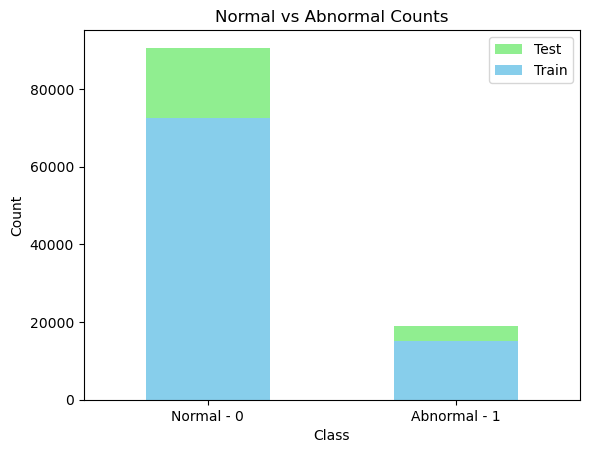

In [44]:
# Replace zero Values in training and Total Plot ECG signal Counts
data2 = data.copy()
signal_cols = data.columns.drop("label")

for idx, row in data2[signal_cols].iterrows():
    non_zero_pos = np.where(row.values != 0)[0]

    if len(non_zero_pos) > 0:
        last_nonzero = non_zero_pos[-1]

        data2.loc[idx, signal_cols[last_nonzero + 1:]] = np.nan


data2['binary_label'] = np.where(data2['label'] == 0, 0, 1)
binary_counts = data2['binary_label'].value_counts().sort_index()


binary_counts_plt = pd.DataFrame({'Train': binary_counts,
                                  'Test': binary_counts_test})

ax = binary_counts_plt.plot(kind='bar', stacked=True, color=['skyblue', 'lightgreen'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal vs Abnormal Counts')
plt.xticks([0, 1], ['Normal - 0', 'Abnormal - 1'], rotation=0)
handles, labels = ax.get_legend_handles_labels()    # Flips the axis so test is above train
plt.legend(handles[::-1], labels[::-1])
plt.show()

After converting the labels, the training data contained 72,471 normal heartbeat segments and 15,083 abnormal heartbeat segments. The test data contained 18,118 normal heartbeat segments and 3,774 abnormal heartbeat segments. This shows that the dataset is imbalanced, with normal heartbeat segments appearing more frequently than abnormal heartbeat segments. 

We can also look at what the ECG waveform signals look like, here we are observing the first 5 ECG signals for each binary label:

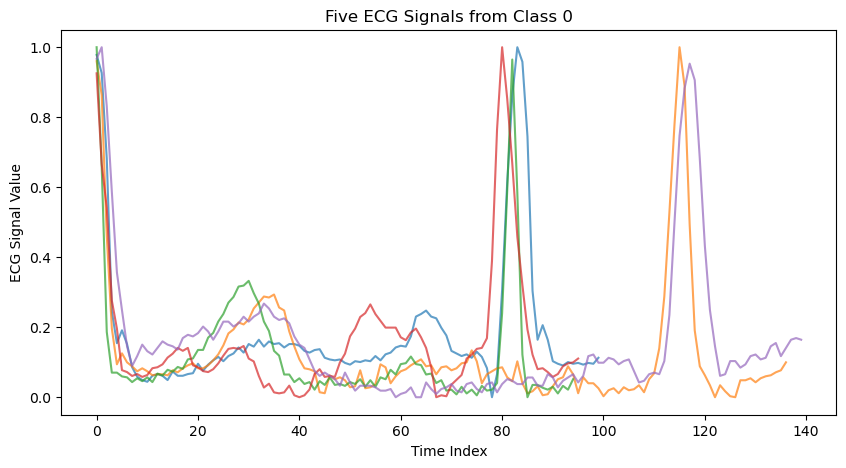

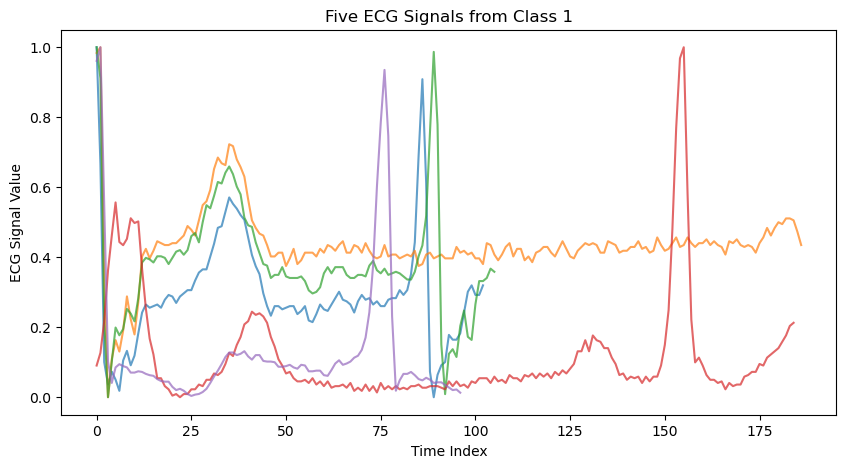

In [45]:
# Plots of each Binary Class
for i in data2['binary_label'].unique():
    subset = data2[data2['binary_label'] == i]

    plt.figure(figsize=(10,5))

    for j in range(5):
        plt.plot(subset.iloc[j, :187], alpha = 0.7)
    
    plt.xlabel('Time Index')
    plt.ylabel('ECG Signal Value')
    plt.title(f'Five ECG Signals from Class {i}')
    plt.show()

<div class="pagebreak"></div>

## Methodology

### Box-Jenkins / ARIMA 

The first method used in this project was the Box-Jenkins approach for fitting ARIMA time series models. I chose not to follow an SARIMA model because the ECG heartbeat signals did not have an obvious seasonal period. I ended up using a nonseasonal ARIMA model, but it can be viewed as a special case of SARIMA model because ARIMA(p, d, q) = SARIMA(p, d, q) x (0, 0, 0).

For the Box-Jenkins analysis, I selected one normal ECG heartbeat signal and one abnormal ECG heartbeat signal from the MIT-BIH training data. Since the heartbeat segments had a fixed length containing a trail of zeros at the end, the trailing zeros were removed from the signals before fitting the ARIMA models.

The Box-Jenkins procedure was applied by first selecting ECG signals and plotting their ACF and PACF plots. Then several candidate ARIMA models were fit to each signal. The models were compared using AIC and BIC. Finally, residual analysis was used to evaluate the models. 

Because ARIMA models are fit to one time series at a time, the selected ARIMA models should be interpreted as models for the specific representative ECG signals analyzed in this project, instead of universal models for every normal or abnormal heartbeat segment.

### Random Forest

In this project, the random forest model was trained on the MIT-BIH training dataset and evaluated on the separate MIT-BIH test dataset. The original five heartbeat labels were converted into a binary response, where original label 0 was treated as normal and original labels 1 through 4 were grouped as abnormal. The trailing zeros were kept for the random forest analysis because the model requires each observation to have the same number of features. However, it is important to note that this also means the model may use both the waveform shape and the trailing zero length when making predictions.

The model was evaluated using several classification metrics. Accuracy was used to measure the overall proportion of correct predictions while precision, recall, and F1 score were used to evaluate performance for each class. Recall for the abnormal class was especially important because it measures how many abnormal heartbeat segments were correctly identified. A confusion matrix was used to show the number of correct and incorrect classifications for normal and abnormal signals. Also, an ROC curve and AUC score was used to evaluate how good the model distinguished between classes. Finally, random forest feature importance was used to identify which ECG time indices helped the most in the classification decision.

<div class="pagebreak"></div>

## Results

ARIMA:

For the Box-Jenkins analysis, one representative normal ECG signal and one representative abnormal ECG signal were selected from the MIT-BIH training data. The trailing zeros were removed before fitting ARIMA models alowing the analysis to focus on the observed ECG waveform.

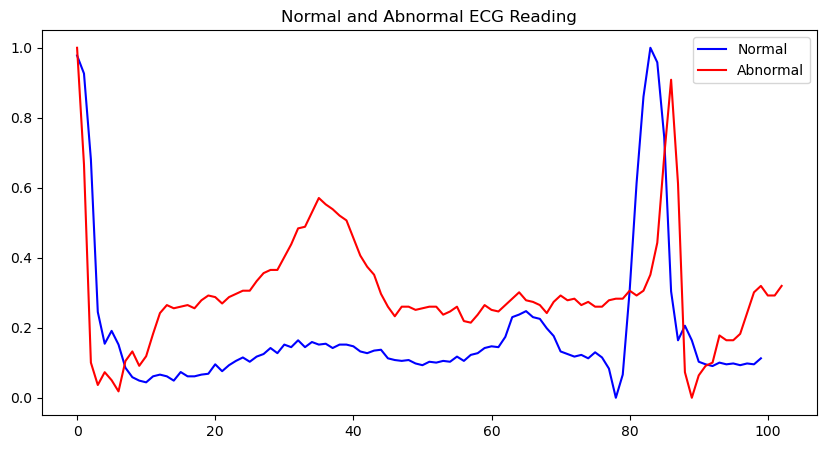

In [46]:
normal = data2[data2['binary_label'] == 0].iloc[0, :187].dropna()
abnormal = data2[data2['binary_label'] == 1].iloc[0, :187].dropna()

normal = normal.reset_index(drop=True)  # Rests the index so we dont get weird time formats
abnormal = abnormal.reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(normal.iloc[:187], label='Normal', color='blue')
plt.plot(abnormal.iloc[:187], label='Abnormal', color='red')
plt.title('Normal and Abnormal ECG Reading')
plt.legend()
plt.show()

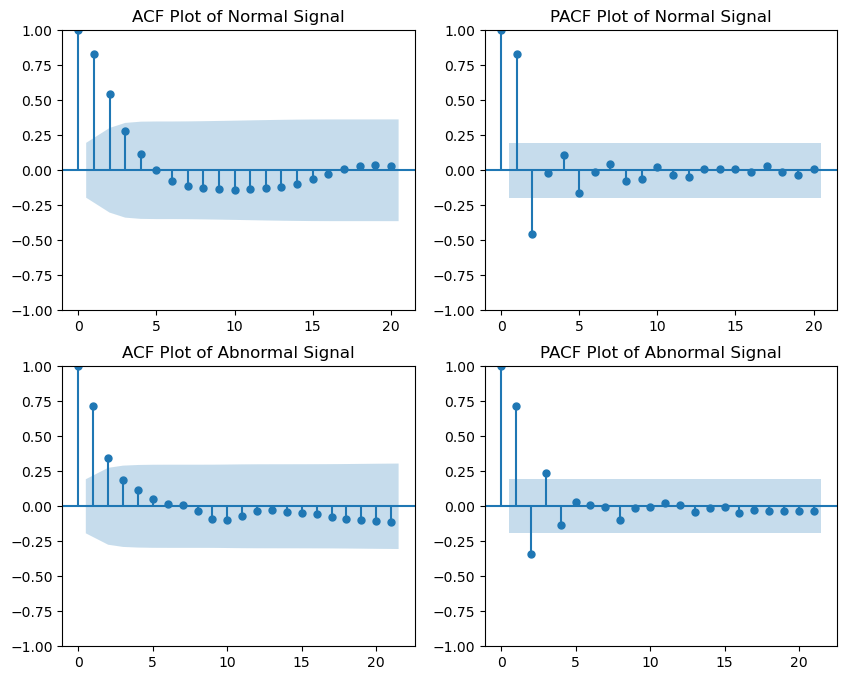

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(normal, ax=axs[0,0], title='ACF Plot of Normal Signal')

plot_pacf(normal, ax=axs[0,1], title='PACF Plot of Normal Signal')

plot_acf(abnormal, ax=axs[1,0], title='ACF Plot of Abnormal Signal')

plot_pacf(abnormal, ax=axs[1,1], title='PACF Plot of Abnormal Signal')
plt.show()

The ACF plots for both signals showed gradual decay, while the PACF plots showed stronger early spikes. This suggested that autoregressive structure was present in both signals.

In [48]:
# Normal AR Model:

# ARIMA(1,0,0)
model_norm_100 = ARIMA(normal, order=(1,0,0))
norm_fit_100 = model_norm_100.fit()
norm_100_aic = norm_fit_100.aic
norm_100_bic = norm_fit_100.bic

# ARIMA(2,0,0)
model_norm_200 = ARIMA(normal, order=(2,0,0))
norm_fit_200 = model_norm_200.fit()
norm_200_aic = norm_fit_200.aic
norm_200_bic = norm_fit_200.bic


model_norm_300 = ARIMA(normal, order=(3,0,0))
norm_fit_300 = model_norm_300.fit()
norm_300_aic = norm_fit_300.aic
norm_300_bic = norm_fit_300.bic

model_norm_400 = ARIMA(normal, order=(4,0,0))
norm_fit_400 = model_norm_400.fit()
norm_400_aic = norm_fit_400.aic
norm_400_bic = norm_fit_400.bic

# Abnormal AR Model:

# ARIMA(1,0,0)
model_ab_100 = ARIMA(abnormal, order=(1,0,0))
ab_fit_100 = model_ab_100.fit()
ab_100_aic = ab_fit_100.aic
ab_100_bic = ab_fit_100.bic

# ARIMA(2,0,0)
model_ab_200 = ARIMA(abnormal, order=(2,0,0))
ab_fit_200 = model_ab_200.fit()
ab_200_aic = ab_fit_200.aic
ab_200_bic = ab_fit_200.bic

model_ab_300 = ARIMA(abnormal, order=(3,0,0))
ab_fit_300 = model_ab_300.fit()
ab_300_aic = ab_fit_300.aic
ab_300_bic = ab_fit_300.bic

model_ab_400 = ARIMA(abnormal, order=(4,0,0))
ab_fit_400 = model_ab_400.fit()
ab_400_aic = ab_fit_400.aic
ab_400_bic = ab_fit_400.bic

ar_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)', 'ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)'], 
         'AIC': [norm_100_aic, norm_200_aic, norm_300_aic, norm_400_aic, ab_100_aic, ab_200_aic, ab_300_aic, ab_400_aic],
         'BIC': [norm_100_bic, norm_200_bic, norm_300_bic, norm_400_bic, ab_100_bic, ab_200_bic, ab_300_bic, ab_400_bic]}

ar_df = pd.DataFrame(ar_table)

# ARIMA Normal:
model_norm_101 = ARIMA(normal, order=(1,0,1))
norm_101_fit = model_norm_101.fit()
norm_101_aic = norm_101_fit.aic
norm_101_bic = norm_101_fit.bic

model_norm_202 = ARIMA(normal, order=(2,0,2))
norm_202_fit = model_norm_202.fit()
norm_202_aic = norm_202_fit.aic
norm_202_bic = norm_202_fit.bic

model_norm_201 = ARIMA(normal, order=(2,0,1))
norm_201_fit = model_norm_201.fit()
norm_201_aic = norm_201_fit.aic
norm_201_bic = norm_201_fit.bic

model_norm_102 = ARIMA(normal, order=(1,0,2))
norm_102_fit = model_norm_102.fit()
norm_102_aic = norm_102_fit.aic
norm_102_bic = norm_102_fit.bic

model_norm_212 = ARIMA(normal, order=(2,1,2))
norm_212_fit = model_norm_212.fit()
norm_212_aic = norm_212_fit.aic
norm_212_bic = norm_212_fit.bic

# ARIMA Abnormal
model_ab_101 = ARIMA(abnormal, order=(1,0,1))
ab_101_fit = model_ab_101.fit()
ab_101_aic = ab_101_fit.aic
ab_101_bic = ab_101_fit.bic

model_ab_202 = ARIMA(abnormal, order=(2,0,2))
ab_202_fit = model_ab_202.fit()
ab_202_aic = ab_202_fit.aic
ab_202_bic = ab_202_fit.bic

model_ab_201 = ARIMA(abnormal, order=(2,0,1))
ab_201_fit = model_ab_201.fit()
ab_201_aic = ab_201_fit.aic
ab_201_bic = ab_201_fit.bic

model_ab_102 = ARIMA(abnormal, order=(1,0,2))
ab_102_fit = model_ab_102.fit()
ab_102_aic = ab_102_fit.aic
ab_102_bic = ab_102_fit.bic

model_ab_212 = ARIMA(abnormal, order=(2,1,2))
ab_212_fit = model_ab_212.fit()
ab_212_aic = ab_212_fit.aic
ab_212_bic = ab_212_fit.bic

arima_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)', 'ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)'], 
         'AIC': [norm_101_aic, norm_202_aic, norm_201_aic, norm_102_aic, norm_212_aic, ab_101_aic, ab_202_aic, ab_201_aic, ab_102_aic, ab_212_aic],
         'BIC': [norm_101_bic, norm_202_bic, norm_201_bic, norm_102_bic, norm_212_bic, ab_101_bic, ab_202_bic, ab_201_bic, ab_102_bic, ab_212_bic]}

arima_df = pd.DataFrame(arima_table)


model_scores = pd.concat([ar_df, arima_df])
model_scores = model_scores.sort_values(by=['AIC', 'BIC'])
model_scores

,signal,Model,AIC,BIC
2,Normal,"ARIMA(2,0,1)",-266.739254,-253.713403
2,Normal,"ARIMA(3,0,0)",-266.167037,-253.141186
3,Normal,"ARIMA(4,0,0)",-265.090729,-249.459708
1,Normal,"ARIMA(2,0,2)",-265.064928,-249.433907
3,Normal,"ARIMA(1,0,2)",-264.301846,-251.275995
4,Normal,"ARIMA(2,1,2)",-262.471396,-249.495797
1,Normal,"ARIMA(2,0,0)",-261.209762,-250.789081
8,Abnormal,"ARIMA(1,0,2)",-248.564096,-235.390451
6,Abnormal,"ARIMA(2,0,2)",-246.771526,-230.963152
0,Normal,"ARIMA(1,0,1)",-246.423046,-236.002365


Based on AIC and BIC, the best model for the normal signal was ARIMA(2,0,1), and the best model for the abnormal signal was ARIMA(1,0,2). 

### Residual Analysis:

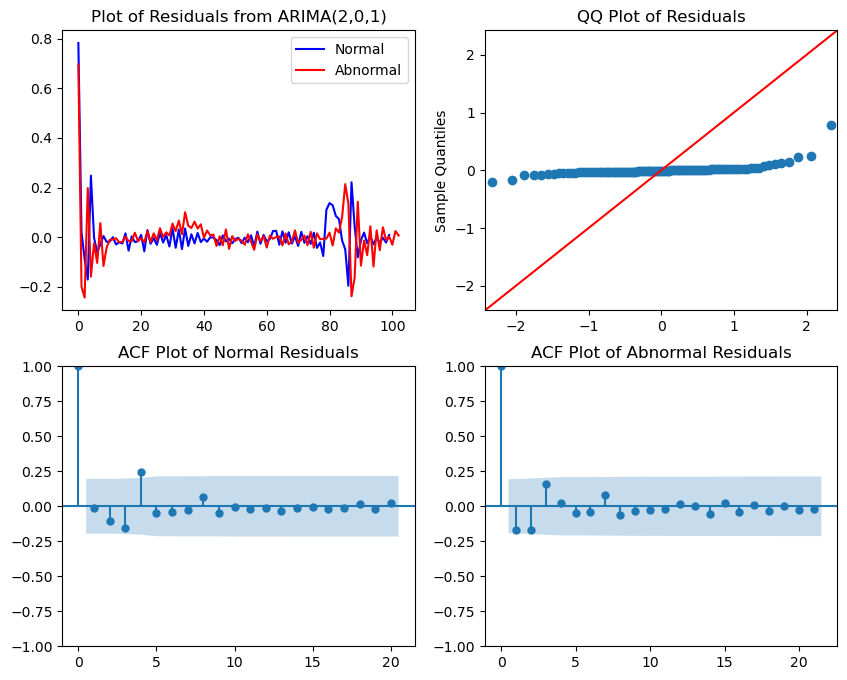

In [59]:
# ARIMA(2,0,1)
resid_norm_201 = norm_201_fit.resid
resid_ab_201 = ab_201_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_201, color='blue', label='Normal')
axs[0,0].plot(resid_ab_201, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(2,0,1)')
axs[0,0].legend()

sm.qqplot(resid_norm_201, line='45', ax=axs[0,1])
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_201, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_201, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


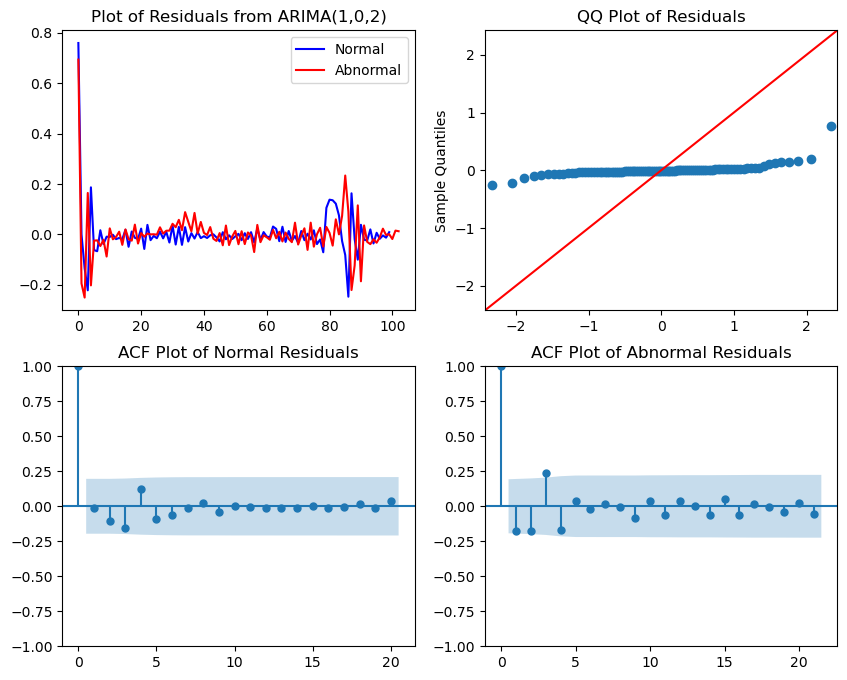

In [50]:
# ARIMA(1,0,2)
resid_norm_102 = norm_102_fit.resid
resid_ab_102 = ab_102_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_102, color='blue', label='Normal')
axs[0,0].plot(resid_ab_102, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(1,0,2)')
axs[0,0].legend()

sm.qqplot(resid_norm_102, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_102, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_102, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


In [51]:
# Ljung-Box Test
norm_lb_test = acorr_ljungbox(resid_norm_201, lags=[5,10,15,20], return_df=True)
ab_lb_test = acorr_ljungbox(resid_ab_102, lags=[5,10,15,20], return_df=True)

norm_lb_test['Signal'] = 'Normal'
ab_lb_test['Signal'] = 'Abnormal'

norm_ab_lb = pd.concat([norm_lb_test, ab_lb_test])
norm_ab_lb

,lb_stat,lb_pvalue,Signal
5,10.363291,0.065572,Normal
10,11.344707,0.331300,Normal
15,11.525831,0.714507,Normal
20,11.762605,0.924005,Normal
5,15.916120,0.007088,Abnormal
10,17.015338,0.074025,Abnormal
15,18.406934,0.241876,Abnormal
20,19.174684,0.510499,Abnormal


The Ljung-Box results mostly show large p-values at higher lags, suggesting that the selected ARIMA models removed much of the autocorrelation from the residuals. However, a few early lags have p-values below 0.05, which suggests that some short-lag autocorrelation may remain. Therefore, the ARIMA models are reasonable but not perfect.

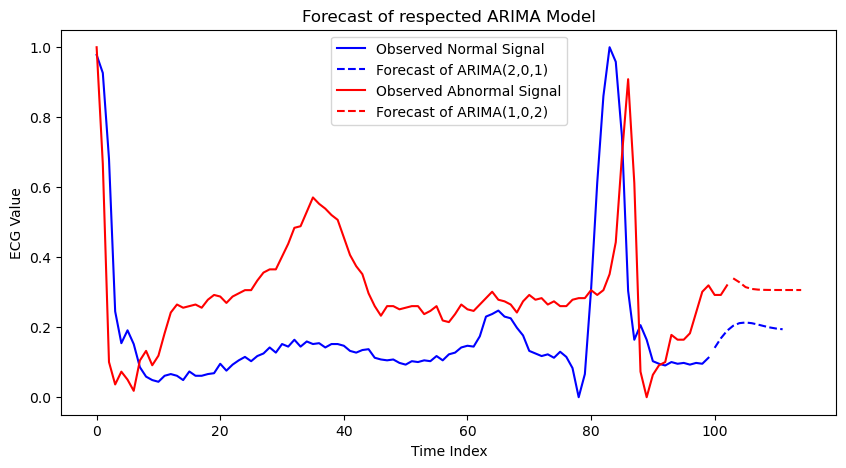

In [52]:
# Normal Forecasting:
forecast_steps = 12
forecast_norm = norm_201_fit.get_forecast(steps=forecast_steps)
forecast_norm_val = forecast_norm.predicted_mean
forecast_norm_ci = forecast_norm.conf_int()
forecast_index_norm = range(len(normal), len(normal) + forecast_steps)

# Abnormal Forecasting:
forecast_ab = ab_102_fit.get_forecast(steps=forecast_steps)
forecast_ab_val = forecast_ab.predicted_mean
forecast_ab_ci = forecast_ab.conf_int()
forecast_index_ab = range(len(abnormal), len(abnormal) + forecast_steps)

plt.figure(figsize=(10,5))

plt.plot(range(len(normal)), normal, label='Observed Normal Signal', 
         color='blue')
plt.plot(forecast_index_norm, forecast_norm_val, label='Forecast of ARIMA(2,0,1)', 
         color='blue', linestyle='dashed')

plt.plot(range(len(abnormal)), abnormal, label='Observed Abnormal Signal', 
         color='red')
plt.plot(forecast_index_ab, forecast_ab_val, label='Forecast of ARIMA(1,0,2)', 
         color='red', linestyle='dashed')

plt.title('Forecast of respected ARIMA Model')
plt.xlabel('Time Index')
plt.ylabel('ECG Value')
plt.legend()
plt.show()

The selected ARIMA models were then used to forecast the next 12 ECG signal values. The forecasts moved toward a more stable level, which is normal for stationary ARMA models.

<div class="pagebreak"></div>

### Random Forest:

After the ARIMA analysis, a Random Forest classifier was trained using the full MIT-BIH training dataset and evaluated on the separate MIT-BIH test dataset. The response variable was the binary label, where 0 represented normal heartbeat segments and 1 represented abnormal heartbeat segments. The predictors were the 187 ECG signal values.


In [53]:
# Training data:
train = data.copy()
train['binary_label'] = np.where(train['label'] == 0, 0, 1)
x_train = train.drop(columns=['label', 'binary_label'])  # X
label = train['label']
y_train = train['binary_label'] # y

# Testing Data:
x_test = test.drop(columns=['label', 'binary_label'])
test_label = test['label']
y_test = test['binary_label']

In [54]:
rf = RandomForestClassifier(n_estimators=100, random_state=123)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

In [55]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 97.78

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.99      0.88      0.93      3774

    accuracy                           0.98     21892
   macro avg       0.98      0.94      0.96     21892
weighted avg       0.98      0.98      0.98     21892



The random forest model achieved high overall accuracy. The classification report shows that the model performed good on normal heartbeat signals, while recall for the abnormal class was slightly lower. This means that some abnormal heartbeat segments were incorrectly classified as normal.

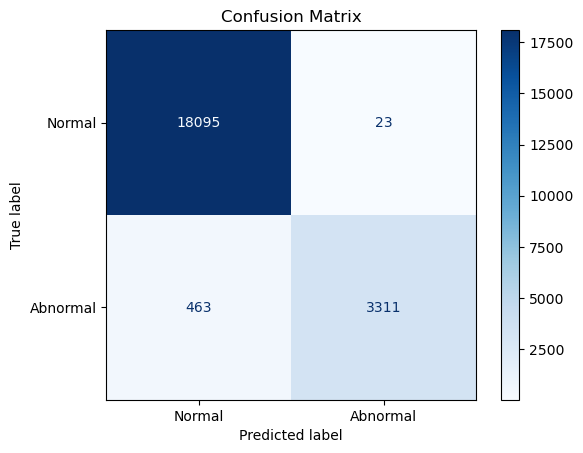

In [56]:
cm = confusion_matrix(y_test, y_pred)
signal = ['Normal', 'Abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=signal)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

Above we have a confusion matrix which gives a more detailed view of the model errors. The most important error in this model is when an abnormal signal gets predicted as normal, because that means a missed abnormal heartbeat. Although the model performed well overall, the confusion matrix shows that this type of error still occurred.

ROC AUC Score: 0.9941


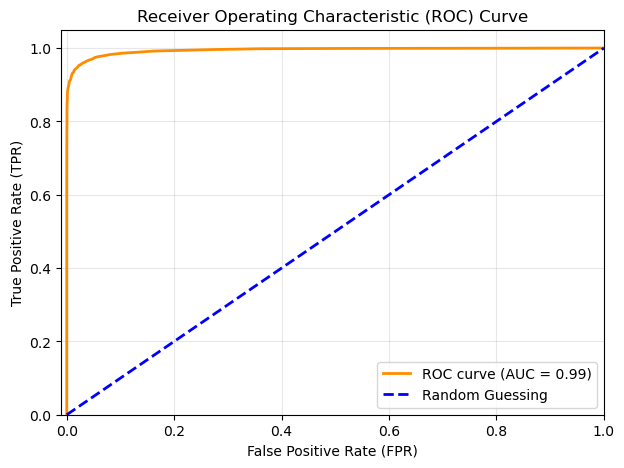

In [57]:
y_prob = rf.predict_proba(x_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--', label='Random Guessing')

# Formatting details
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


The ROC curve and AUC score were used to evaluate how well the Random Forest separated normal and abnormal signals across classification thresholds. A high AUC value indicates that the model had strong ability to distinguish between the two classes.

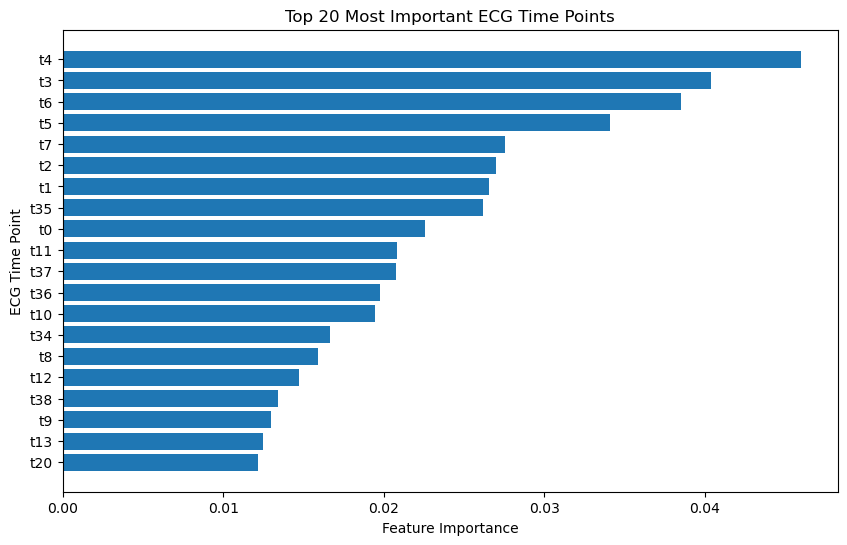

In [58]:
# Get feature importances from the random forest model
importances = rf.feature_importances_

# ECG time indices: 0, 1, 2, ..., 186
time_index = np.arange(len(importances))

top_n = 20
top_indices = np.argsort(importances)[-top_n:]

# Sort top features from least to most important for plotting
top_indices_sorted = top_indices[np.argsort(importances[top_indices])]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"t{idx}" for idx in top_indices_sorted],
    importances[top_indices_sorted]
)

plt.xlabel('Feature Importance')
plt.ylabel('ECG Time Point')
plt.title('Top 20 Most Important ECG Time Points')
plt.show()

The random forest feature importance plot shows which ECG time indices contributed most to the classification decision. Because the predictors are ordered ECG signal values, this plot helps identify which parts of the heartbeat waveform were most useful for distinguishing normal and abnormal signals.

One limitation is that the ECG signals are stored as fixed length vectors with trailing zeros. If the model assigns high importance to later time indices, it may be using information related to signal length or padding in addition to waveform shape. This does not appear to be the case here as the most important features appear earlier in the time indices, indicating that the model does not heavily rely on the trailing zeros.  

<div class="pagebreak"></div>

## Conclusion

This project analyzed ECG heartbeat signals using both classical time series modeling and machine learning classification methods. The data came from the ECG Heartbeat Categorization Dataset, with the main analysis focusing on the MIT-BIH heartbeat train and test files. The original five heartbeat classes were converted into a binary classification problem where label 0 represented a normal heartbeat and labels 1 through 4 represented abnormal heartbeats.

For the time series portion of the project, I applied the Box-Jenkins approach to one representative normal ECG signal and one representative abnormal ECG signal. After removing trailing zero from the signals, I examined the raw signal plots, ACF plots, and PACF plots. The ACF and PACF patterns suggested autoregressive structure, so several ARIMA and ARMA models were fit and compared using AIC and BIC. The selected model for the representative normal signal was ARIMA(2,0,1), while the selected model for the representative abnormal signal was ARIMA(1,0,2). These results suggest that the selected normal and abnormal heartbeat signals had different short term dependence structures. The residual analysis and Ljung-Box tests showed that the models removed some of the autocorrelation, though some shortvterm structure was still present.

For the machine learning portion, I used a random forest classifier to predict if each ECG heartbeat segment was normal or abnormal. The random forest model used the 187 ECG signal values as predictors and was trained on the MIT-BIH training data, then evaluated on the testing data. The model achieved a strong classification performance, however the abnormal class was slightly harder to classify than the normal class. This is important to note because missing abnormal heartbeat signals would be a more serious type of error in a medical setting.

For future plans of study, first instead of selecting only one normal and one abnormal signal for ARIMA modeling, I would fit ARIMA models to many heartbeat segments and compare how it performs. Second, the project could be expanded from binary classification to the original five heartbeat classes. This would allow the model to distinguish between different types of abnormal heartbeat patterns. Third, future work could use more advanced deep learning methods such as a 1D convolutional neural network or a LSTM model. 

<div class="pagebreak"></div>

## Appendix

Dataset: https://www.kaggle.com/datasets/shayanfazeli/heartbeat/data

### Entire python code:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm    # Used for plotting qq-plot
from statsmodels.stats.diagnostic import acorr_ljungbox     # Used in the Ljung-Box test
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
```

```python
data = pd.read_csv('data/mitbih_train.csv', header=None)
data.columns = (list(range(187))) + ['label']

signal = data.drop(columns='label')
label = data['label']

print(data.head())
print(data.shape)
print(data.isna().any())

counts = label.value_counts().sort_index()
print(counts)
```

In [95]:
print(data.head())
print(data.shape)
print(data.isna().any())

counts = label.value_counts().sort_index()
print(counts)

          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  label  
0  0.0    0.0  
1  0.0    0.0  
2  0.0    0.0  
3  0

```python
# Counts plot:
counts.plot(kind='bar')
plt.xlabel('ECG Reading')
plt.ylabel('Count')
plt.show()
```

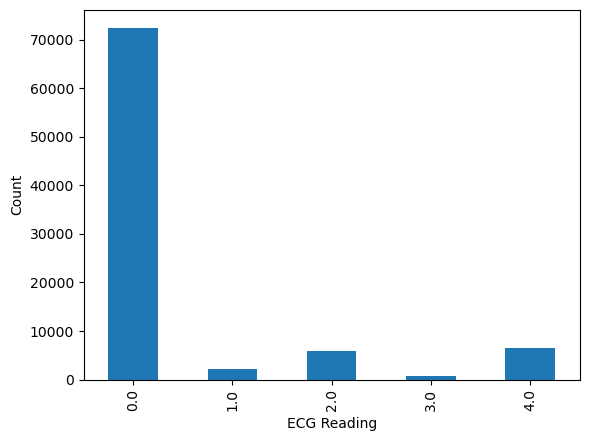

In [96]:
counts.plot(kind='bar')
plt.xlabel('ECG Reading')
plt.ylabel('Count')
plt.show()

```python
# There is a trail of zeros for a lot of the observations
# This plot shows the amount of zeros in each column
signal_clean=signal.replace(0, None)
zero_counts = signal_clean.isna().sum()
zero_counts.plot(kind='bar')
plt.show()
```

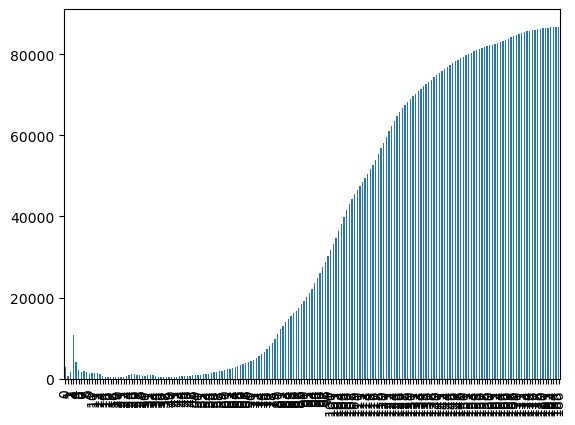

In [97]:
signal_clean=signal.replace(0, None)
zero_counts = signal_clean.isna().sum()
zero_counts.plot(kind='bar')
plt.show()

```python
# Replace the trialing zeros with Nan
data2 = data.copy()
signal_cols = data.columns.drop("label")

for idx, row in data2[signal_cols].iterrows():
    non_zero_pos = np.where(row.values != 0)[0]

    if len(non_zero_pos) > 0:
        last_nonzero = non_zero_pos[-1]

        data2.loc[idx, signal_cols[last_nonzero + 1:]] = np.nan
```

In [84]:
data2 = data.copy()
signal_cols = data.columns.drop("label")

for idx, row in data2[signal_cols].iterrows():
    non_zero_pos = np.where(row.values != 0)[0]

    if len(non_zero_pos) > 0:
        last_nonzero = non_zero_pos[-1]

        data2.loc[idx, signal_cols[last_nonzero + 1:]] = np.nan

```python
# plots of each type of ECG reading
for i in sorted(data2['label'].unique()):
    class_data = data2[data2['label'] == i]

    plt.figure(figsize=(10,5))

    for j in range(5):
        plt.plot(class_data.iloc[j, :187], alpha=0.7)

    plt.xlabel('Time Index')
    plt.ylabel('ECG Signal Value')
    plt.title(f'Five ECG Signals from Class {i}')
    plt.show()
```

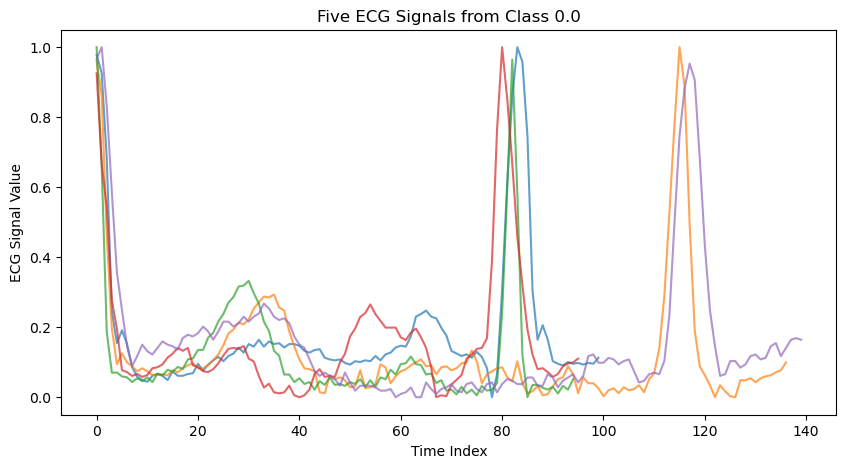

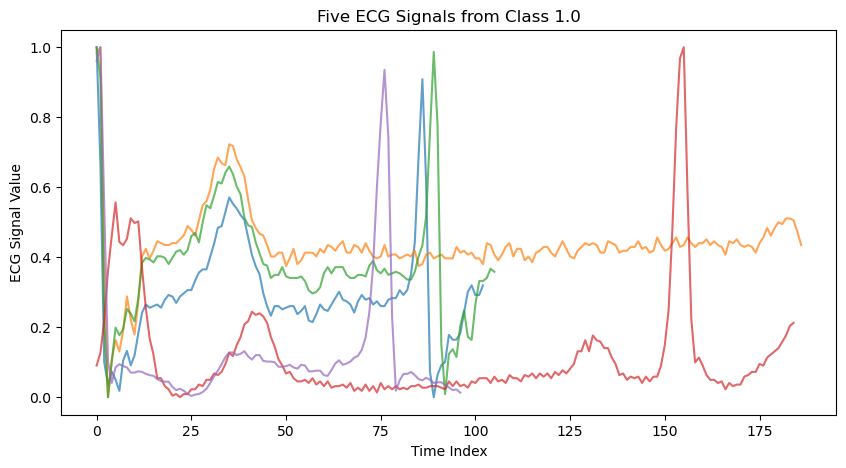

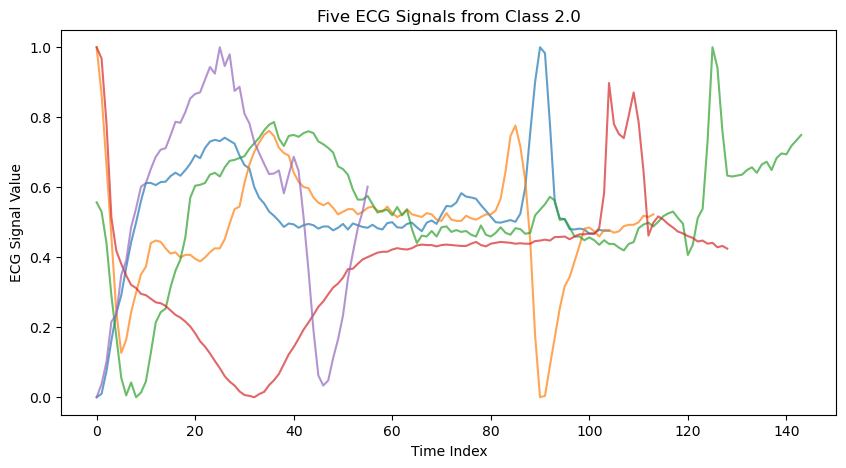

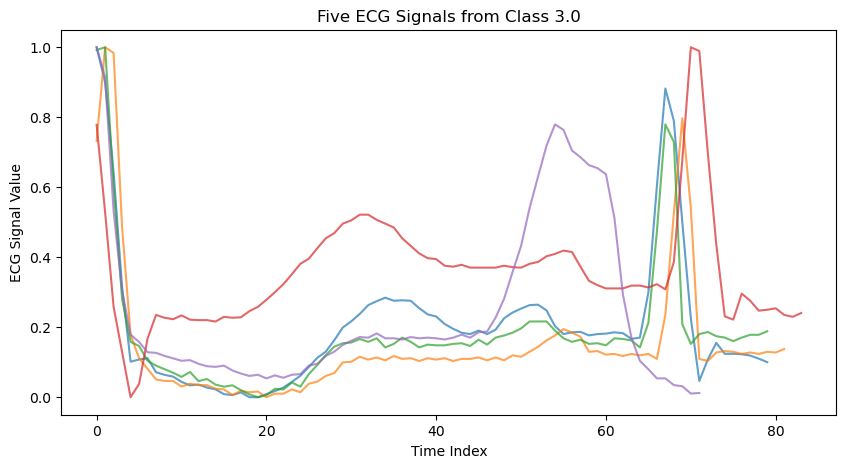

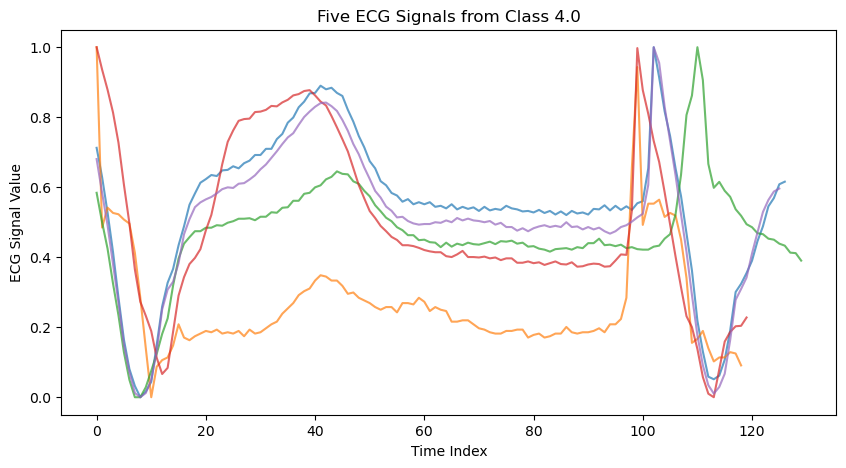

In [85]:
# plots of each type of ECG reading
for i in sorted(data2['label'].unique()):
    class_data = data2[data2['label'] == i]

    plt.figure(figsize=(10,5))

    for j in range(5):
        plt.plot(class_data.iloc[j, :187], alpha=0.7)

    plt.xlabel('Time Index')
    plt.ylabel('ECG Signal Value')
    plt.title(f'Five ECG Signals from Class {i}')
    plt.show()

```python 
data2['binary_label'] = np.where(data2['label'] == 0, 0, 1)
binary_counts = data2['binary_label'].value_counts().sort_index()
print(binary_counts)

binary_counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal vs Abnormal Counts')
plt.xticks([0, 1], ['Normal', 'Abnormal'], rotation=0)
plt.show()
```

binary_label
0    72471
1    15083
Name: count, dtype: int64


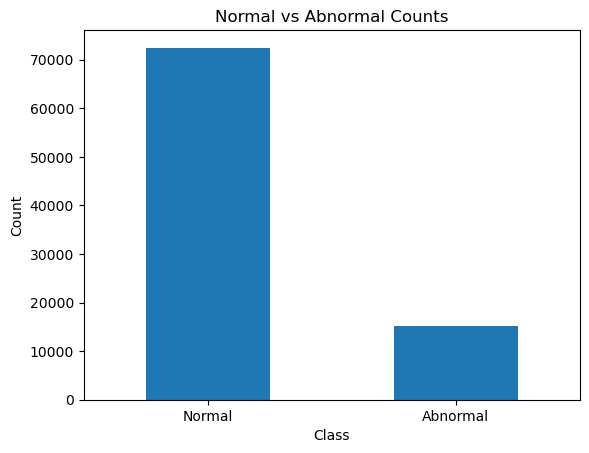

In [86]:
data2['binary_label'] = np.where(data2['label'] == 0, 0, 1)
binary_counts = data2['binary_label'].value_counts().sort_index()
print(binary_counts)

binary_counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal vs Abnormal Counts')
plt.xticks([0, 1], ['Normal', 'Abnormal'], rotation=0)
plt.show()

```python
normal = data2[data2['binary_label'] == 0].iloc[0, :187].dropna()
abnormal = data2[data2['binary_label'] == 1].iloc[0, :187].dropna()

normal = normal.reset_index(drop=True)  # Rests the index so we dont get weird time formats
abnormal = abnormal.reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(normal.iloc[:187], label='Normal', color='blue')
plt.plot(abnormal.iloc[:187], label='Abnormal', color='red')
plt.title('Normal and Abnormal ECG Reading')
plt.legend()
plt.show()
```

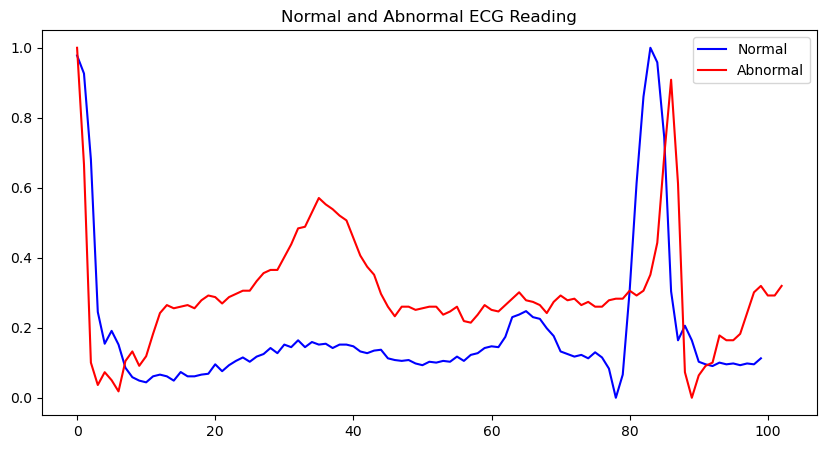

In [87]:
normal = data2[data2['binary_label'] == 0].iloc[0, :187].dropna()
abnormal = data2[data2['binary_label'] == 1].iloc[0, :187].dropna()

normal = normal.reset_index(drop=True)  # Rests the index so we dont get weird time formats
abnormal = abnormal.reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(normal.iloc[:187], label='Normal', color='blue')
plt.plot(abnormal.iloc[:187], label='Abnormal', color='red')
plt.title('Normal and Abnormal ECG Reading')
plt.legend()
plt.show()

```python
# ACF and PACF Plots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(normal, ax=axs[0,0], title='ACF Plot of Normal Signal')

plot_pacf(normal, ax=axs[0,1], title='PACF Plot of Normal Signal')

plot_acf(abnormal, ax=axs[1,0], title='ACF Plot of Abnormal Signal')

plot_pacf(abnormal, ax=axs[1,1], title='PACF Plot of Abnormal Signal')
plt.show()
```

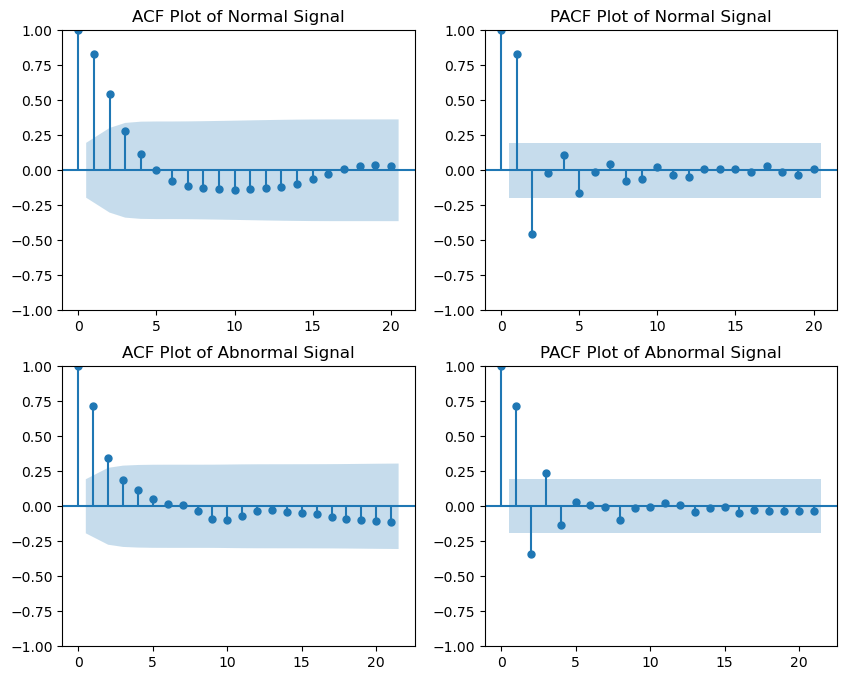

In [88]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(normal, ax=axs[0,0], title='ACF Plot of Normal Signal')

plot_pacf(normal, ax=axs[0,1], title='PACF Plot of Normal Signal')

plot_acf(abnormal, ax=axs[1,0], title='ACF Plot of Abnormal Signal')

plot_pacf(abnormal, ax=axs[1,1], title='PACF Plot of Abnormal Signal')
plt.show()

```python
# Check if data is stationary and if we need to apply a differencing:
stationary = adfuller(normal)
print(f'ADF Statistic: {stationary[0]}')
print(f'p-value: {stationary[1]}')
# Since our p-value is small, this suggests our data is stationary and we do not need a difference factor
```

In [89]:
# Check if data is stationary and if we need to apply a differencing:
stationary = adfuller(normal)
print(f'ADF Statistic: {stationary[0]}')
print(f'p-value: {stationary[1]}')

ADF Statistic: -4.137487190665371
p-value: 0.0008391988892750893


```python
# Model Fitting:

# Normal AR Model:

# ARIMA(1,0,0)
model_norm_100 = ARIMA(normal, order=(1,0,0))
norm_fit_100 = model_norm_100.fit()
norm_100_aic = norm_fit_100.aic
norm_100_bic = norm_fit_100.bic

# ARIMA(2,0,0)
model_norm_200 = ARIMA(normal, order=(2,0,0))
norm_fit_200 = model_norm_200.fit()
norm_200_aic = norm_fit_200.aic
norm_200_bic = norm_fit_200.bic


model_norm_300 = ARIMA(normal, order=(3,0,0))
norm_fit_300 = model_norm_300.fit()
norm_300_aic = norm_fit_300.aic
norm_300_bic = norm_fit_300.bic

model_norm_400 = ARIMA(normal, order=(4,0,0))
norm_fit_400 = model_norm_400.fit()
norm_400_aic = norm_fit_400.aic
norm_400_bic = norm_fit_400.bic

# Abnormal AR Model:

# ARIMA(1,0,0)
model_ab_100 = ARIMA(abnormal, order=(1,0,0))
ab_fit_100 = model_ab_100.fit()
ab_100_aic = ab_fit_100.aic
ab_100_bic = ab_fit_100.bic

# ARIMA(2,0,0)
model_ab_200 = ARIMA(abnormal, order=(2,0,0))
ab_fit_200 = model_ab_200.fit()
ab_200_aic = ab_fit_200.aic
ab_200_bic = ab_fit_200.bic

model_ab_300 = ARIMA(abnormal, order=(3,0,0))
ab_fit_300 = model_ab_300.fit()
ab_300_aic = ab_fit_300.aic
ab_300_bic = ab_fit_300.bic

model_ab_400 = ARIMA(abnormal, order=(4,0,0))
ab_fit_400 = model_ab_400.fit()
ab_400_aic = ab_fit_400.aic
ab_400_bic = ab_fit_400.bic

ar_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)', 'ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)'], 
         'AIC': [norm_100_aic, norm_200_aic, norm_300_aic, norm_400_aic, ab_100_aic, ab_200_aic, ab_300_aic, ab_400_aic],
         'BIC': [norm_100_bic, norm_200_bic, norm_300_bic, norm_400_bic, ab_100_bic, ab_200_bic, ab_300_bic, ab_400_bic]}

ar_df = pd.DataFrame(ar_table)
ar_df

In [90]:
# Model Fitting:

# Normal AR Model:

# ARIMA(1,0,0)
model_norm_100 = ARIMA(normal, order=(1,0,0))
norm_fit_100 = model_norm_100.fit()
norm_100_aic = norm_fit_100.aic
norm_100_bic = norm_fit_100.bic

# ARIMA(2,0,0)
model_norm_200 = ARIMA(normal, order=(2,0,0))
norm_fit_200 = model_norm_200.fit()
norm_200_aic = norm_fit_200.aic
norm_200_bic = norm_fit_200.bic


model_norm_300 = ARIMA(normal, order=(3,0,0))
norm_fit_300 = model_norm_300.fit()
norm_300_aic = norm_fit_300.aic
norm_300_bic = norm_fit_300.bic

model_norm_400 = ARIMA(normal, order=(4,0,0))
norm_fit_400 = model_norm_400.fit()
norm_400_aic = norm_fit_400.aic
norm_400_bic = norm_fit_400.bic

# Abnormal AR Model:

# ARIMA(1,0,0)
model_ab_100 = ARIMA(abnormal, order=(1,0,0))
ab_fit_100 = model_ab_100.fit()
ab_100_aic = ab_fit_100.aic
ab_100_bic = ab_fit_100.bic

# ARIMA(2,0,0)
model_ab_200 = ARIMA(abnormal, order=(2,0,0))
ab_fit_200 = model_ab_200.fit()
ab_200_aic = ab_fit_200.aic
ab_200_bic = ab_fit_200.bic

model_ab_300 = ARIMA(abnormal, order=(3,0,0))
ab_fit_300 = model_ab_300.fit()
ab_300_aic = ab_fit_300.aic
ab_300_bic = ab_fit_300.bic

model_ab_400 = ARIMA(abnormal, order=(4,0,0))
ab_fit_400 = model_ab_400.fit()
ab_400_aic = ab_fit_400.aic
ab_400_bic = ab_fit_400.bic

ar_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)', 'ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)'], 
         'AIC': [norm_100_aic, norm_200_aic, norm_300_aic, norm_400_aic, ab_100_aic, ab_200_aic, ab_300_aic, ab_400_aic],
         'BIC': [norm_100_bic, norm_200_bic, norm_300_bic, norm_400_bic, ab_100_bic, ab_200_bic, ab_300_bic, ab_400_bic]}

ar_df = pd.DataFrame(ar_table)

```python
# More model Fitting:

# ARIMA Normal:
model_norm_101 = ARIMA(normal, order=(1,0,1))
norm_101_fit = model_norm_101.fit()
norm_101_aic = norm_101_fit.aic
norm_101_bic = norm_101_fit.bic

model_norm_202 = ARIMA(normal, order=(2,0,2))
norm_202_fit = model_norm_202.fit()
norm_202_aic = norm_202_fit.aic
norm_202_bic = norm_202_fit.bic

model_norm_201 = ARIMA(normal, order=(2,0,1))
norm_201_fit = model_norm_201.fit()
norm_201_aic = norm_201_fit.aic
norm_201_bic = norm_201_fit.bic

model_norm_102 = ARIMA(normal, order=(1,0,2))
norm_102_fit = model_norm_102.fit()
norm_102_aic = norm_102_fit.aic
norm_102_bic = norm_102_fit.bic

model_norm_212 = ARIMA(normal, order=(2,1,2))
norm_212_fit = model_norm_212.fit()
norm_212_aic = norm_212_fit.aic
norm_212_bic = norm_212_fit.bic

# ARIMA Abnormal
model_ab_101 = ARIMA(abnormal, order=(1,0,1))
ab_101_fit = model_ab_101.fit()
ab_101_aic = ab_101_fit.aic
ab_101_bic = ab_101_fit.bic

model_ab_202 = ARIMA(abnormal, order=(2,0,2))
ab_202_fit = model_ab_202.fit()
ab_202_aic = ab_202_fit.aic
ab_202_bic = ab_202_fit.bic

model_ab_201 = ARIMA(abnormal, order=(2,0,1))
ab_201_fit = model_ab_201.fit()
ab_201_aic = ab_201_fit.aic
ab_201_bic = ab_201_fit.bic

model_ab_102 = ARIMA(abnormal, order=(1,0,2))
ab_102_fit = model_ab_102.fit()
ab_102_aic = ab_102_fit.aic
ab_102_bic = ab_102_fit.bic

model_ab_212 = ARIMA(abnormal, order=(2,1,2))
ab_212_fit = model_ab_212.fit()
ab_212_aic = ab_212_fit.aic
ab_212_bic = ab_212_fit.bic

arima_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)', 'ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)'], 
         'AIC': [norm_101_aic, norm_202_aic, norm_201_aic, norm_102_aic, norm_212_aic, ab_101_aic, ab_202_aic, ab_201_aic, ab_102_aic, ab_212_aic],
         'BIC': [norm_101_bic, norm_202_bic, norm_201_bic, norm_102_bic, norm_212_bic, ab_101_bic, ab_202_bic, ab_201_bic, ab_102_bic, ab_212_bic]}

arima_df = pd.DataFrame(arima_table)

model_scores = pd.concat([ar_df, arima_df])
model_scores = model_scores.sort_values(by=['AIC', 'BIC'], ascending=False)
model_scores
```

In [91]:
# More model Fitting:

# ARIMA Normal:
model_norm_101 = ARIMA(normal, order=(1,0,1))
norm_101_fit = model_norm_101.fit()
norm_101_aic = norm_101_fit.aic
norm_101_bic = norm_101_fit.bic

model_norm_202 = ARIMA(normal, order=(2,0,2))
norm_202_fit = model_norm_202.fit()
norm_202_aic = norm_202_fit.aic
norm_202_bic = norm_202_fit.bic

model_norm_201 = ARIMA(normal, order=(2,0,1))
norm_201_fit = model_norm_201.fit()
norm_201_aic = norm_201_fit.aic
norm_201_bic = norm_201_fit.bic

model_norm_102 = ARIMA(normal, order=(1,0,2))
norm_102_fit = model_norm_102.fit()
norm_102_aic = norm_102_fit.aic
norm_102_bic = norm_102_fit.bic

model_norm_212 = ARIMA(normal, order=(2,1,2))
norm_212_fit = model_norm_212.fit()
norm_212_aic = norm_212_fit.aic
norm_212_bic = norm_212_fit.bic

# ARIMA Abnormal
model_ab_101 = ARIMA(abnormal, order=(1,0,1))
ab_101_fit = model_ab_101.fit()
ab_101_aic = ab_101_fit.aic
ab_101_bic = ab_101_fit.bic

model_ab_202 = ARIMA(abnormal, order=(2,0,2))
ab_202_fit = model_ab_202.fit()
ab_202_aic = ab_202_fit.aic
ab_202_bic = ab_202_fit.bic

model_ab_201 = ARIMA(abnormal, order=(2,0,1))
ab_201_fit = model_ab_201.fit()
ab_201_aic = ab_201_fit.aic
ab_201_bic = ab_201_fit.bic

model_ab_102 = ARIMA(abnormal, order=(1,0,2))
ab_102_fit = model_ab_102.fit()
ab_102_aic = ab_102_fit.aic
ab_102_bic = ab_102_fit.bic

model_ab_212 = ARIMA(abnormal, order=(2,1,2))
ab_212_fit = model_ab_212.fit()
ab_212_aic = ab_212_fit.aic
ab_212_bic = ab_212_fit.bic

arima_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)', 'ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)'], 
         'AIC': [norm_101_aic, norm_202_aic, norm_201_aic, norm_102_aic, norm_212_aic, ab_101_aic, ab_202_aic, ab_201_aic, ab_102_aic, ab_212_aic],
         'BIC': [norm_101_bic, norm_202_bic, norm_201_bic, norm_102_bic, norm_212_bic, ab_101_bic, ab_202_bic, ab_201_bic, ab_102_bic, ab_212_bic]}

arima_df = pd.DataFrame(arima_table)

model_scores = pd.concat([ar_df, arima_df])
model_scores = model_scores.sort_values(by=['AIC', 'BIC'], ascending=False)
model_scores

,signal,Model,AIC,BIC
4,Abnormal,"ARIMA(1,0,0)",-179.695124,-171.790937
0,Normal,"ARIMA(1,0,0)",-191.104343,-183.288832
5,Abnormal,"ARIMA(2,0,0)",-221.731205,-211.192289
5,Abnormal,"ARIMA(1,0,1)",-234.041034,-223.502118
6,Abnormal,"ARIMA(3,0,0)",-234.205735,-221.032090
9,Abnormal,"ARIMA(2,1,2)",-235.822719,-222.697855
7,Abnormal,"ARIMA(2,0,1)",-240.059116,-226.885471
7,Abnormal,"ARIMA(4,0,0)",-243.283491,-227.475117
0,Normal,"ARIMA(1,0,1)",-246.423046,-236.002365
6,Abnormal,"ARIMA(2,0,2)",-246.771526,-230.963152


```python
# ARIMA(2,0,1)
resid_norm_201 = norm_201_fit.resid
resid_ab_201 = ab_201_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_201, color='blue', label='Normal')
axs[0,0].plot(resid_ab_201, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(2,0,1)')
axs[0,0].legend()

sm.qqplot(resid_norm_201, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_201, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_201, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()
```

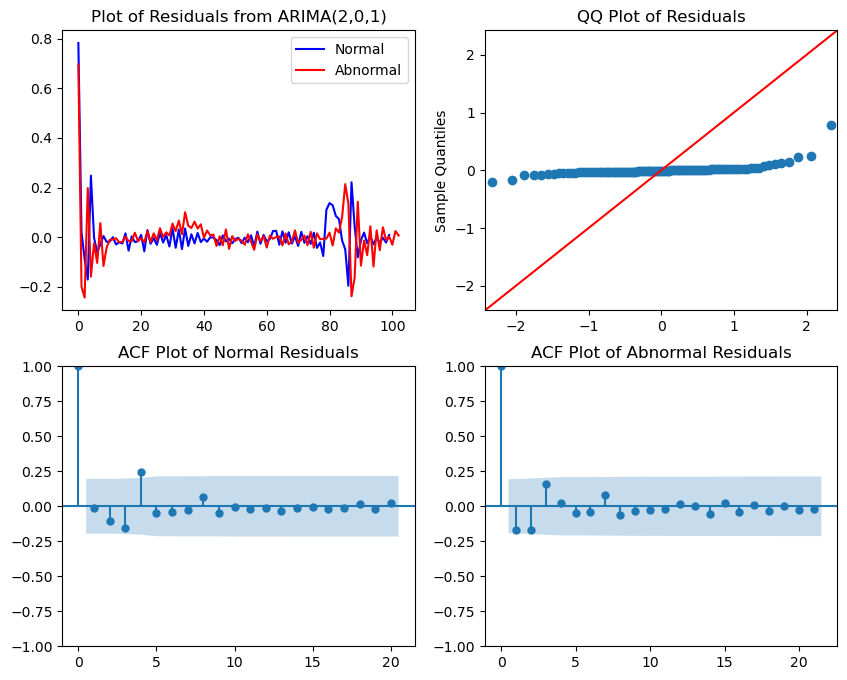

In [103]:
# ARIMA(2,0,1)
resid_norm_201 = norm_201_fit.resid
resid_ab_201 = ab_201_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_201, color='blue', label='Normal')
axs[0,0].plot(resid_ab_201, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(2,0,1)')
axs[0,0].legend()

sm.qqplot(resid_norm_201, line='45', ax=axs[0,1])
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_201, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_201, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


```python
# ARIMA(1,0,2)
resid_norm_102 = norm_102_fit.resid
resid_ab_102 = ab_102_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_102, color='blue', label='Normal')
axs[0,0].plot(resid_ab_102, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(1,0,2)')
axs[0,0].legend()

sm.qqplot(resid_norm_102, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_102, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_102, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()
```

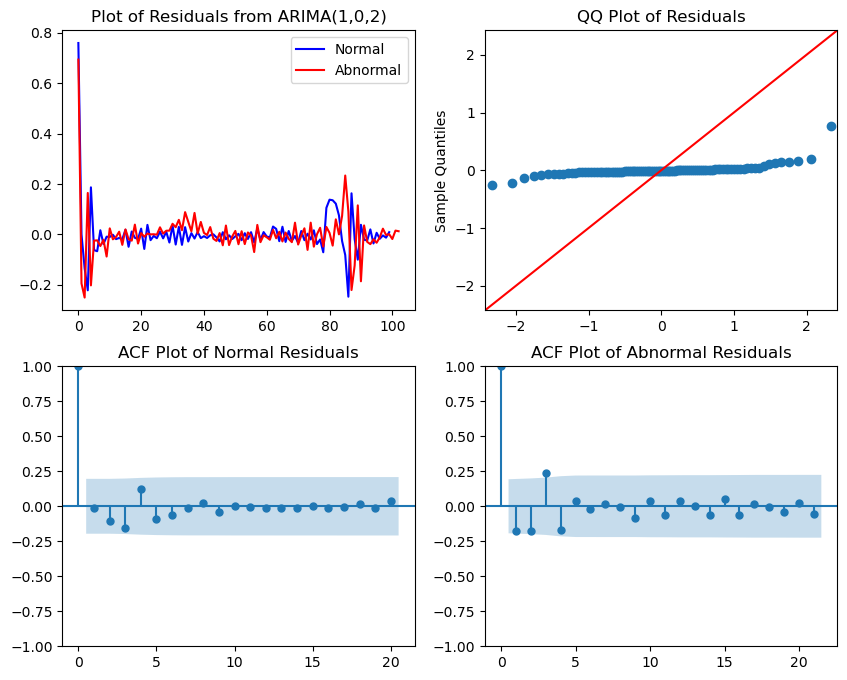

In [93]:
# ARIMA(1,0,2)
resid_norm_102 = norm_102_fit.resid
resid_ab_102 = ab_102_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_102, color='blue', label='Normal')
axs[0,0].plot(resid_ab_102, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(1,0,2)')
axs[0,0].legend()

sm.qqplot(resid_norm_102, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_102, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_102, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


```python
# Ljung-Box Test
norm_lb_test = acorr_ljungbox(resid_norm_201, lags=[5,10,15,20], return_df=True)
ab_lb_test = acorr_ljungbox(resid_ab_102, lags=[5,10,15,20], return_df=True)

norm_lb_test['Signal'] = 'Normal'
ab_lb_test['Signal'] = 'Abnormal'

norm_ab_lb = pd.concat([norm_lb_test, ab_lb_test])
norm_ab_lb
```

In [94]:
# Ljung-Box Test
norm_lb_test = acorr_ljungbox(resid_norm_201, lags=[5,10,15,20], return_df=True)
ab_lb_test = acorr_ljungbox(resid_ab_102, lags=[5,10,15,20], return_df=True)

norm_lb_test['Signal'] = 'Normal'
ab_lb_test['Signal'] = 'Abnormal'

norm_ab_lb = pd.concat([norm_lb_test, ab_lb_test])
norm_ab_lb

,lb_stat,lb_pvalue,Signal
5,10.363291,0.065572,Normal
10,11.344707,0.331300,Normal
15,11.525831,0.714507,Normal
20,11.762605,0.924005,Normal
5,15.916120,0.007088,Abnormal
10,17.015338,0.074025,Abnormal
15,18.406934,0.241876,Abnormal
20,19.174684,0.510499,Abnormal


```python
# Normal Forecasting:
forecast_steps = 12
forecast_norm = norm_201_fit.get_forecast(steps=forecast_steps)
forecast_norm_val = forecast_norm.predicted_mean
forecast_norm_ci = forecast_norm.conf_int()
forecast_index_norm = range(len(normal), len(normal) + forecast_steps)

# Abnormal Forecasting:
forecast_ab = ab_102_fit.get_forecast(steps=forecast_steps)
forecast_ab_val = forecast_ab.predicted_mean
forecast_ab_ci = forecast_ab.conf_int()
forecast_index_ab = range(len(abnormal), len(abnormal) + forecast_steps)

plt.figure(figsize=(10,5))

plt.plot(range(len(normal)), normal, label='Observed Normal Signal', 
         color='blue')
plt.plot(forecast_index_norm, forecast_norm_val, label='Forecast of ARIMA(2,0,1)', 
         color='blue', linestyle='dashed')

plt.plot(range(len(abnormal)), abnormal, label='Observed Abnormal Signal', 
         color='red')
plt.plot(forecast_index_ab, forecast_ab_val, label='Forecast of ARIMA(1,0,2)', 
         color='red', linestyle='dashed')

plt.title('Forecast of respected ARIMA Model')
plt.xlabel('Time Index')
plt.ylabel('ECG Value')
plt.legend()
plt.show()
```

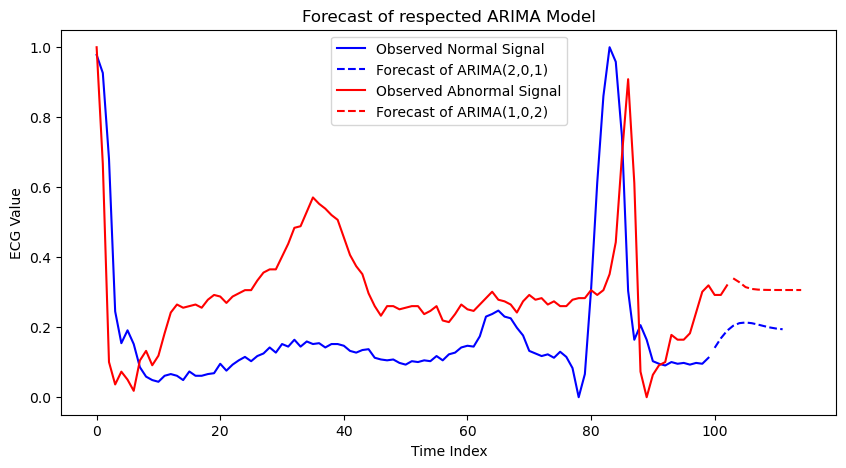

In [98]:
plt.figure(figsize=(10,5))

plt.plot(range(len(normal)), normal, label='Observed Normal Signal', 
         color='blue')
plt.plot(forecast_index_norm, forecast_norm_val, label='Forecast of ARIMA(2,0,1)', 
         color='blue', linestyle='dashed')

plt.plot(range(len(abnormal)), abnormal, label='Observed Abnormal Signal', 
         color='red')
plt.plot(forecast_index_ab, forecast_ab_val, label='Forecast of ARIMA(1,0,2)', 
         color='red', linestyle='dashed')

plt.title('Forecast of respected ARIMA Model')
plt.xlabel('Time Index')
plt.ylabel('ECG Value')
plt.legend()
plt.show()

## Random Forest Section:

```python
# Training data:
train = pd.read_csv('data/mitbih_train.csv', header=None)
train.columns = (list(range(187))) + ['label']
train['binary_label'] = np.where(train['label'] == 0, 0, 1)

x_train = train.drop(columns=['label', 'binary_label'])  # X
label = train['label']
y_train = train['binary_label'] # y

# Testing Data:
test = pd.read_csv('data/mitbih_test.csv', header=None)
test.columns = (list(range(187))) + ['label']
test['binary_label'] = np.where(test['label'] == 0, 0, 1)

x_test = test.drop(columns=['label', 'binary_label'])
test_label = test['label']
y_test = test['binary_label']
```

```python
# Model
rf = RandomForestClassifier(n_estimators=100, random_state=123)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
```

```python
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}")
print("\nClassification Report:\n", classification_rep)
```

In [99]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 97.78

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     18118
           1       0.99      0.88      0.93      3774

    accuracy                           0.98     21892
   macro avg       0.98      0.94      0.96     21892
weighted avg       0.98      0.98      0.98     21892



```python
# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
signal = ['Normal', 'Abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=signal)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()
```

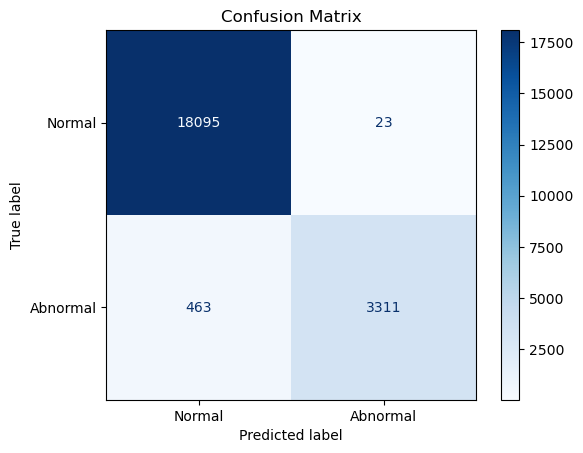

In [100]:
# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
signal = ['Normal', 'Abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=signal)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

```python
# ROC and AUC
y_prob = rf.predict_proba(x_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

# Formatting details
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
```

ROC AUC Score: 0.9941


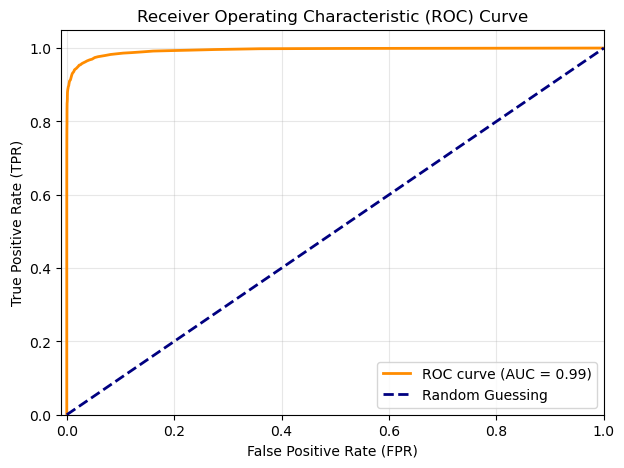

In [101]:
y_prob = rf.predict_proba(x_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

# Formatting details
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


```python
# Get feature importances from the random forest model
importances = rf.feature_importances_

# ECG time indices: 0, 1, 2, ..., 186
time_index = np.arange(len(importances))

# Get indices of the top 20 most important features
top_n = 20
top_indices = np.argsort(importances)[-top_n:]

# Sort those top features from least to most important for plotting
top_indices_sorted = top_indices[np.argsort(importances[top_indices])]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"t{idx}" for idx in top_indices_sorted],
    importances[top_indices_sorted]
)

plt.xlabel('Feature Importance')
plt.ylabel('ECG Time Point')
plt.title('Top 20 Most Important ECG Time Points')
plt.show()
```

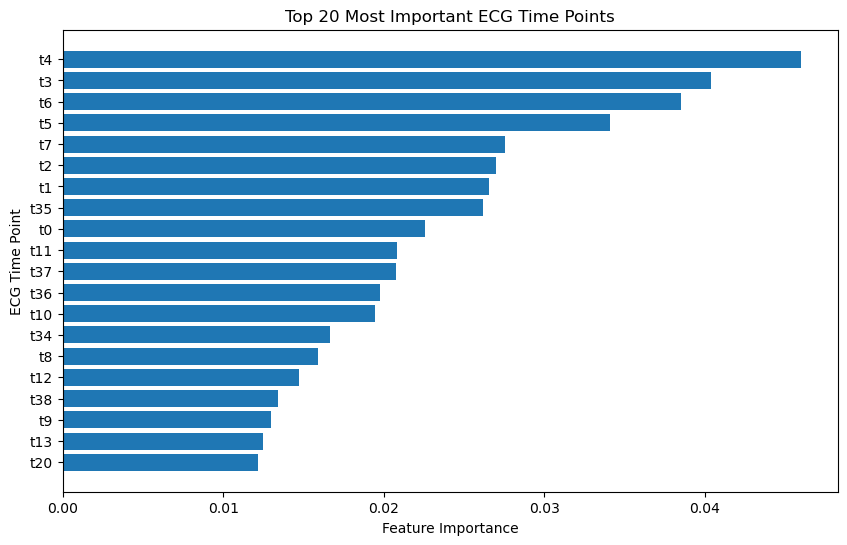

In [102]:
# Get feature importances from the random forest model
importances = rf.feature_importances_

# ECG time indices: 0, 1, 2, ..., 186
time_index = np.arange(len(importances))

# Get indices of the top 20 most important features
top_n = 20
top_indices = np.argsort(importances)[-top_n:]

# Sort those top features from least to most important for plotting
top_indices_sorted = top_indices[np.argsort(importances[top_indices])]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"t{idx}" for idx in top_indices_sorted],
    importances[top_indices_sorted]
)

plt.xlabel('Feature Importance')
plt.ylabel('ECG Time Point')
plt.title('Top 20 Most Important ECG Time Points')
plt.show()